In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/Users/yash/Documents/LocalProjects/crop-diseases-detection/paddy-disease-classification/train_images',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 8384 files belonging to 10 classes.


In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/Users/yash/Documents/LocalProjects/crop-diseases-detection/paddy-disease-classification/valid_images',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 2023 files belonging to 10 classes.


## Building Model

In [4]:
cnn = tf.keras.models.Sequential()

### Building Convolution Layer

In [5]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [7]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [9]:
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))


In [10]:
cnn.add(tf.keras.layers.Dropout(0.25))

In [11]:
cnn.add(tf.keras.layers.GlobalAveragePooling2D())

In [12]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))

In [13]:
cnn.add(tf.keras.layers.Dropout(0.4)) #To avoid overfitting

In [14]:
#Output Layer
cnn.add(tf.keras.layers.Dense(units=10,activation='softmax'))

### Compiling and Training

In [15]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [16]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │       769,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        15,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,496,734 (20.97 MB)

 Trainable params: 5,496,734 (20.97 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.2038 - loss: 2.1500 - val_accuracy: 0.3287 - val_loss: 1.8616
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.3597 - loss: 1.7919 - val_accuracy: 0.4182 - val_loss: 1.6994
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.4586 - loss: 1.5446 - val_accuracy: 0.4884 - val_loss: 1.4310
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 318s 1s/step - accuracy: 0.5456 - loss: 1.3159 - val_accuracy: 0.5215 - val_loss: 1.3385
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.6282 - loss: 1.1252 - val_accuracy: 0.7261 - val_loss: 0.8687
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - accuracy: 0.7308 - loss: 0.8309 - val_accuracy: 0.7346 - val_loss: 0.8733
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 333s 1s/step - accuracy: 0.7938 - loss: 0.6504 - val_accuracy: 0.7884 - val_loss: 0.6545
Epoch 8/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 330s 1s/step - accuracy: 0.8381 - loss: 0.5266 - val_accu

## Evaluating Model

In [18]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

262/262 ━━━━━━━━━━━━━━━━━━━━ 77s 295ms/step - accuracy: 0.9338 - loss: 0.2177
Training accuracy: 0.9380963444709778


In [19]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 295ms/step - accuracy: 0.8768 - loss: 0.4334
Validation accuracy: 0.877409815788269


### Saving Model

In [20]:
cnn.save('paddy_disease_images_model.keras')

In [21]:
training_history.history #Return Dictionary of history

{'accuracy': [0.2544131577014923,
  0.3812022805213928,
  0.4695849120616913,
  0.567628800868988,
  0.651121199131012,
  0.7429627776145935,
  0.8006917834281921,
  0.8425572514533997,
  0.8857347369194031,
  0.9076812863349915],
 'loss': [2.040191888809204,
  1.7300926446914673,
  1.5011461973190308,
  1.2558194398880005,
  1.0559916496276855,
  0.7910557985305786,
  0.6221283078193665,
  0.4959271252155304,
  0.3603445589542389,
  0.2939254641532898],
 'val_accuracy': [0.32871973514556885,
  0.4181908071041107,
  0.48838359117507935,
  0.5215027332305908,
  0.7261492609977722,
  0.7345526218414307,
  0.7884330153465271,
  0.8141373991966248,
  0.852694034576416,
  0.877409815788269],
 'val_loss': [1.8615949153900146,
  1.6994454860687256,
  1.4310054779052734,
  1.3385392427444458,
  0.868736982345581,
  0.87334805727005,
  0.6544731259346008,
  0.5790444612503052,
  0.47540736198425293,
  0.4262970983982086]}

In [23]:
#Recording History in json
import json
with open('image_training_hist.json','w') as f:
  json.dump(training_history.history,f)

## Accuracy Visualization

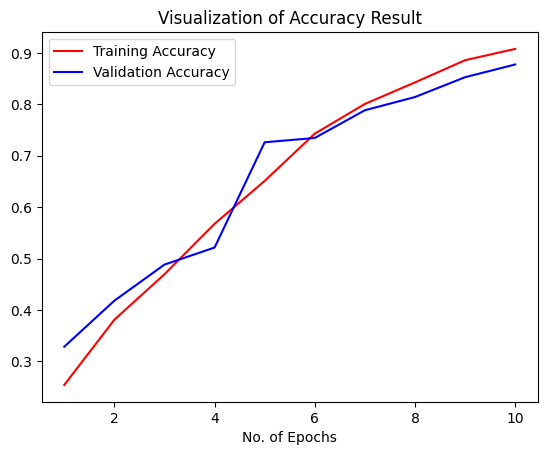

In [24]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Some other matrics for model evaluation

In [31]:
class_name = validation_set.class_names

In [32]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/Users/yash/Documents/LocalProjects/crop-diseases-detection/paddy-disease-classification/valid_images',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 2023 files belonging to 10 classes.


In [33]:
y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

2023/2023 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step


In [34]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/Users/yash/Documents/LocalProjects/crop-diseases-detection/paddy-disease-classification/valid_images',
    labels="inferred",
    label_mode="categorical",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False
)

Found 2023 files belonging to 10 classes.


In [35]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [36]:
Y_true

<tf.Tensor: shape=(2023,), dtype=int64, numpy=array([0, 0, 0, ..., 9, 9, 9])>

In [37]:
predicted_categories

<tf.Tensor: shape=(2023,), dtype=int64, numpy=array([0, 0, 2, ..., 9, 9, 9])>

In [39]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [40]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                          precision    recall  f1-score   support

   bacterial_leaf_blight       0.75      0.82      0.78        96
   bacterial_leaf_streak       0.90      0.86      0.88        76
bacterial_panicle_blight       0.93      0.91      0.92        68
                   blast       0.93      0.86      0.90       348
              brown_spot       0.81      0.86      0.84       193
              dead_heart       0.98      0.93      0.95       228
            downy_mildew       0.82      0.77      0.80       124
                   hispa       0.87      0.92      0.89       319
                  normal       0.85      0.91      0.88       353
                  tungro       0.89      0.83      0.86       218

                accuracy                           0.88      2023
               macro avg       0.87      0.87      0.87      2023
            weighted avg       0.88      0.88      0.88      2023



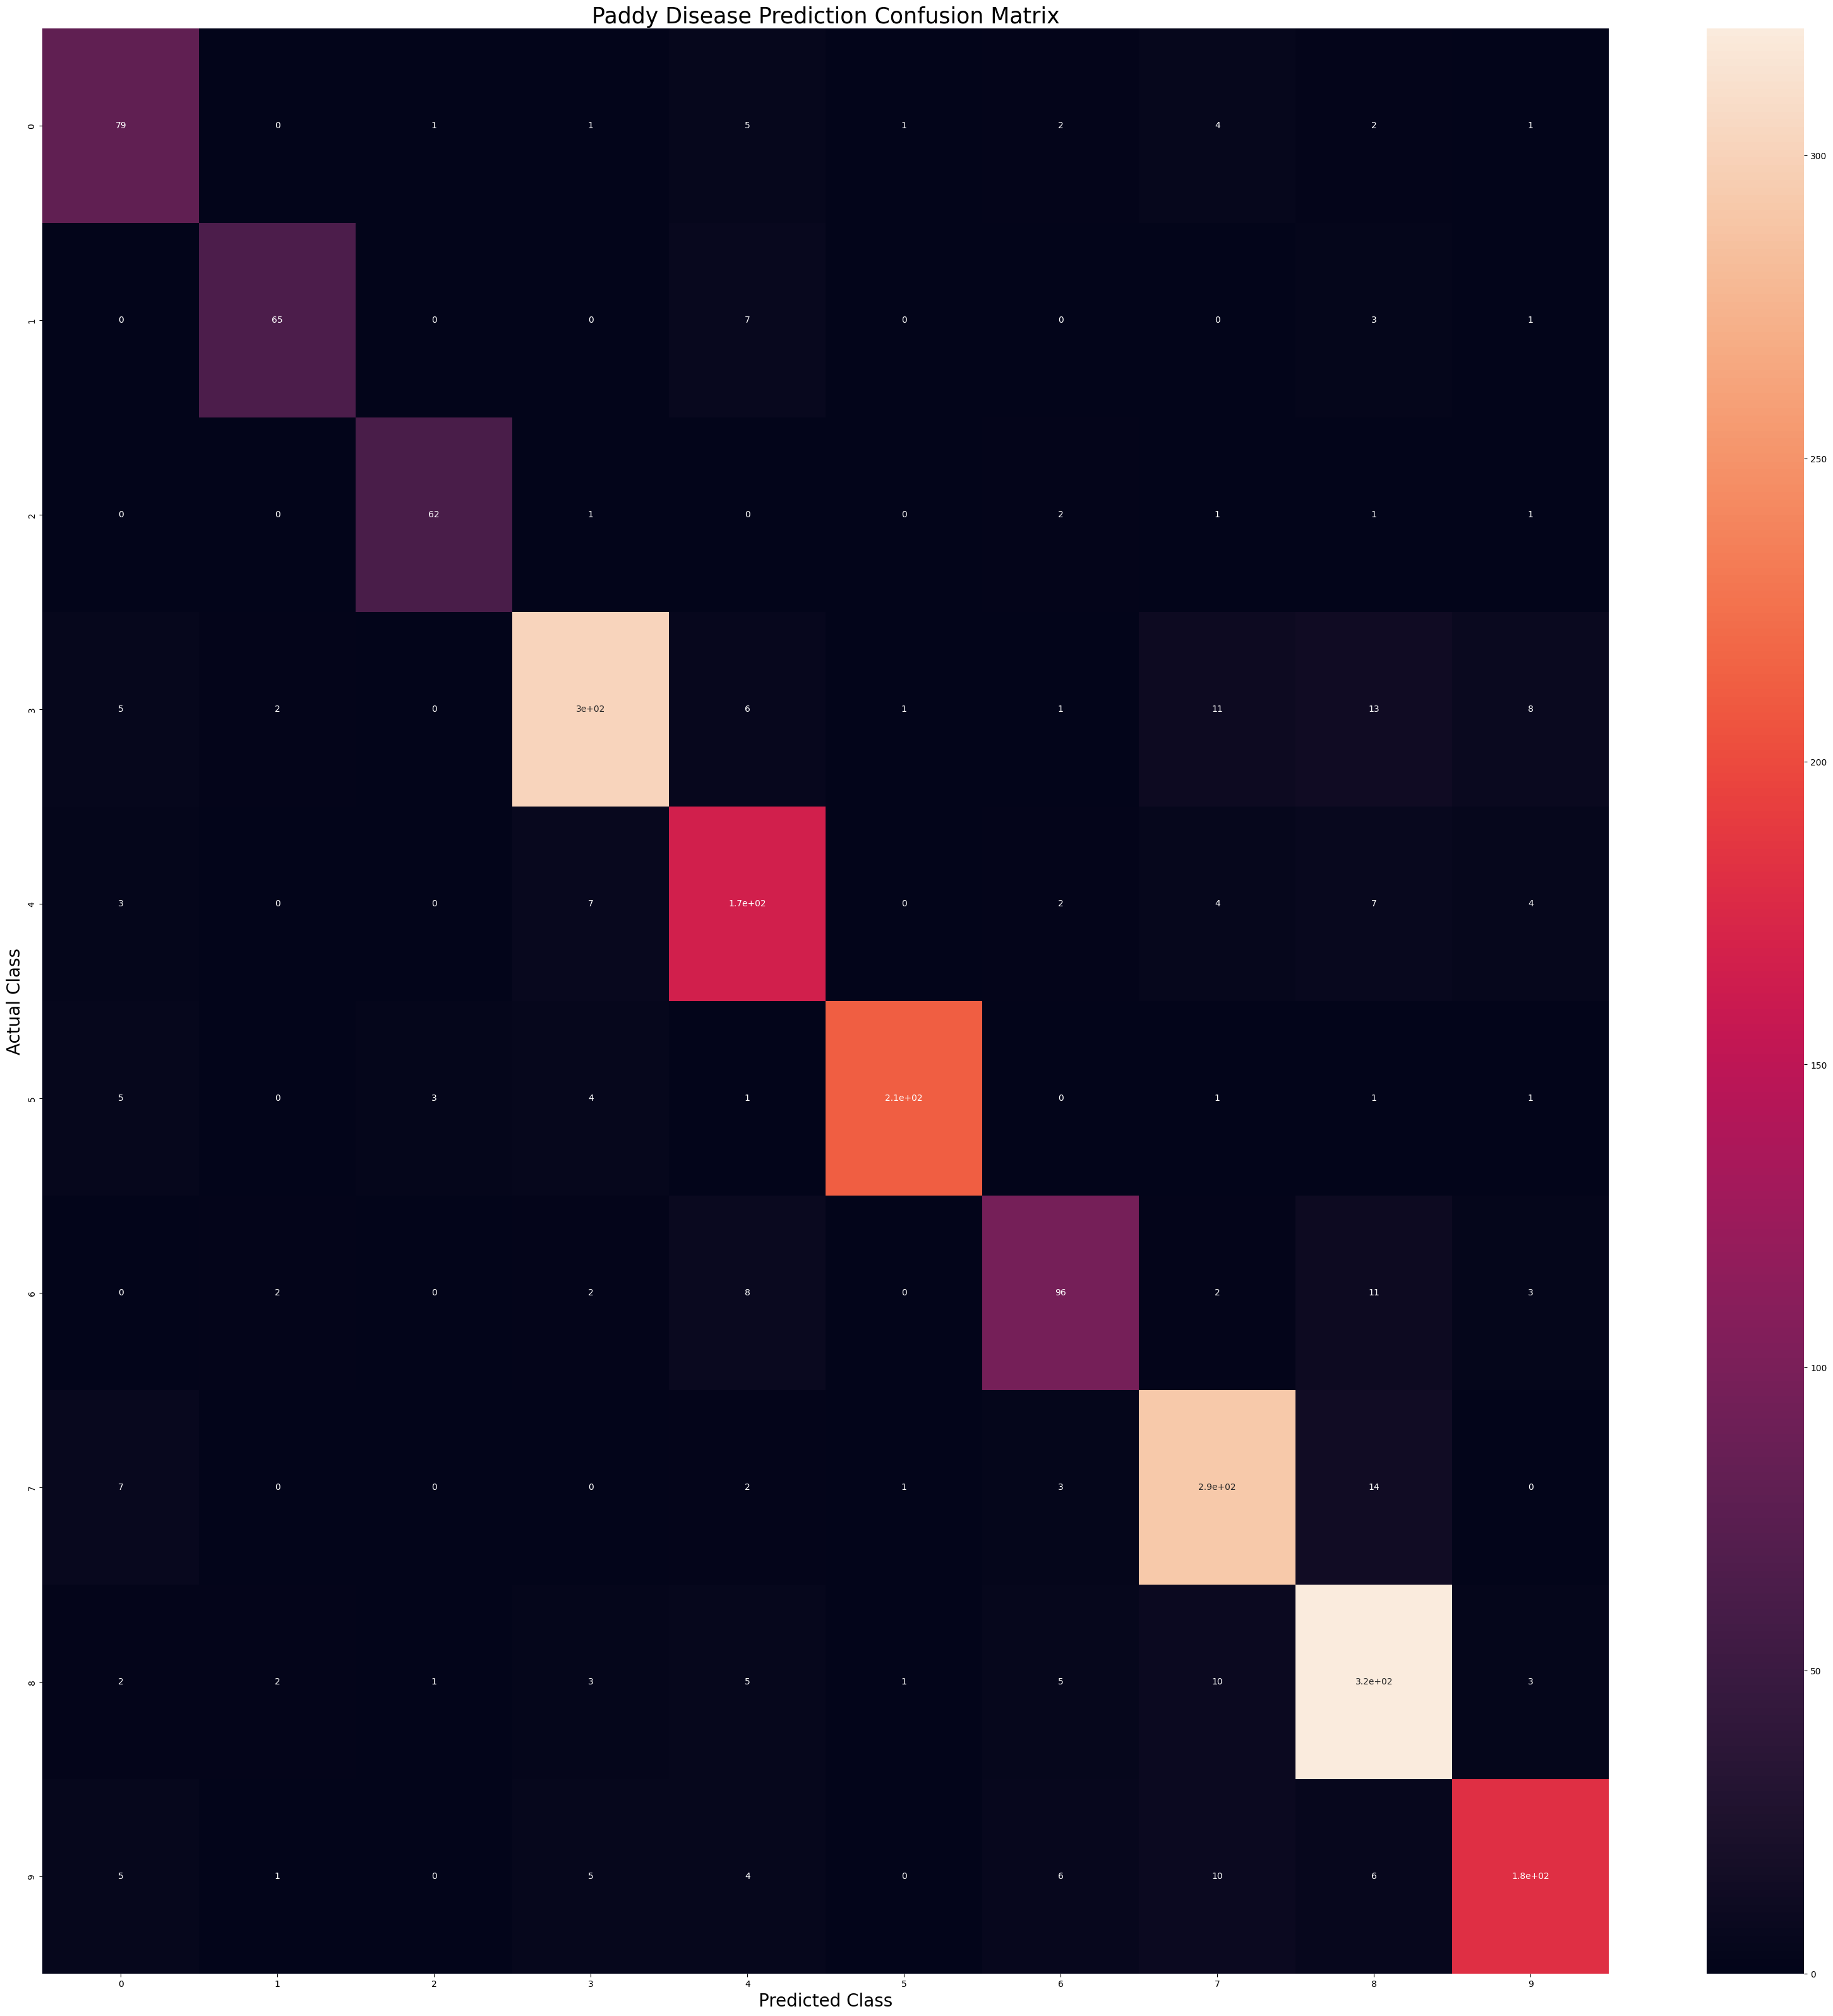

In [41]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Paddy Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()